In [1]:
import torch
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

## Crawl Dog Breeds

In [ ]:
import os
from icrawler.builtin import BingImageCrawler
from PIL import Image, ImageFile

def download_dog_breeds(
    breeds,
    root_dir="data_dog_breeds",
    num_images=250,
    verbose=True
):
    os.makedirs(root_dir, exist_ok=True)

    for breed in breeds:
        folder_name = breed.replace(" ", "_")
        save_path = os.path.join(root_dir, folder_name)
        os.makedirs(save_path, exist_ok=True)

        if verbose:
            print(f"📥 Downloading '{breed}' into '{save_path}'")

        crawler = BingImageCrawler(storage={"root_dir": save_path})
        crawler.crawl(keyword=f"{breed} dog", max_num=num_images)

        # Validate images after download
        if verbose:
            print(f"🧹 Validating images in '{save_path}'")
        validate_images(save_path)

# Allow PIL to load truncated images (instead of crashing)
ImageFile.LOAD_TRUNCATED_IMAGES = True

def validate_images(folder_path):
    """
    Delete unreadable or corrupted images from a folder.
    """
    removed = 0
    total = 0
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        total += 1
        try:
            with Image.open(file_path) as img:
                img.verify()  # Check file integrity
        except Exception:
            os.remove(file_path)
            removed += 1
            print(f"❌ Removed corrupted image: {file_path}")
    
    print(f"✅ Verified {total} images, removed {removed} invalid files.")

In [3]:
dog_breeds = [
    "Bichon Frise", "Bulldog", "Chihuahua", "Collie",
    "German Shepherd Dog", "Siberian Husky", "Pug", "Beagle",
    "Akita", "Bull Terrier", "Basset Hound", "Dalmatian",
]

In [4]:
# Umcomment the following line to download bing images for the dog breeds
# download_dog_breeds(dog_breeds)

In [5]:
# Uncomment the following lines to validate images in the downloaded folders
# for breed in os.listdir("data_dog_breeds"):
#     validate_images(os.path.join("data_dog_breeds", breed))

In [3]:
import os
import matplotlib.pyplot as plt

def analyze_breed_distribution(data_dir):
    """
    Analyze and visualize the distribution of dog breeds in the dataset.

    Args:
        data_dir (str): Root directory where each subfolder is a breed.
    """
    breed_counts = {}
    
    for breed in os.listdir(data_dir):
        breed_path = os.path.join(data_dir, breed)
        if os.path.isdir(breed_path):
            num_images = len([
                file for file in os.listdir(breed_path)
                if file.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
            breed_counts[breed.replace("_", " ")] = num_images

    # Print stats
    # print("📊 Breed Distribution:")
    # for breed, count in sorted(breed_counts.items(), key=lambda x: x[1], reverse=True):
    #     print(f"{breed:<25} {count} images")

    # Plot
    plt.figure(figsize=(8, 4))
    plt.barh(list(breed_counts.keys()), list(breed_counts.values()), color="skyblue")
    plt.xlabel("Number of Images")
    plt.ylabel("Dog Breed")
    plt.title("Distribution of Dog Breeds in Dataset")
    plt.tight_layout()
    plt.show()

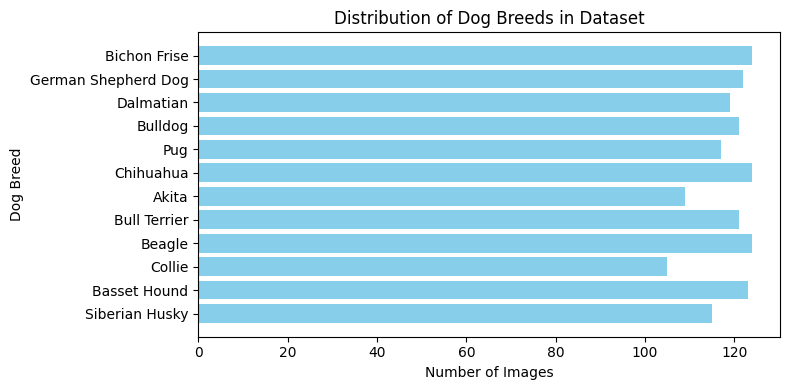

In [4]:
# View the distribution of dog breeds
analyze_breed_distribution("data_dog_breeds")

## Configurations

In [8]:
# Configurations
DATA_DIR = "data_dog_breeds"
CHECKPOINT_DIR = "checkpoints"
RUNS_DIR = "runs"
EPOCHS = 5
BATCH_SIZE = 32
INPUT_SIZE = 224
MEAN = [0.5, 0.5, 0.5]
STD = [0.5, 0.5, 0.5]
NUM_WORKERS = 4
NUM_CLASSES = 12
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load Data

In [9]:
def get_transforms(input_size=224, mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)):
    """
    Returns a tuple (train_transform, val_transform).
    train_transform includes strong augmentations; val_transform is just resize & center-crop.
    """
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(input_size, scale=(0.6, 1.0), ratio=(0.75, 1.33)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.RandomApply([
            transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2)
        ], p=0.8),
        transforms.RandomAutocontrast(p=0.5),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=10),
        transforms.RandomErasing(p=0.6, scale=(0.02, 0.2), ratio=(0.3, 3.3)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val_transform = transforms.Compose([
        transforms.Resize(int(input_size * 256 / 224)),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    
    return train_transform, val_transform

In [ ]:
def load_data(data_dir, batch_size, input_size=INPUT_SIZE, mean=MEAN, std=STD):
    """
    Load dataset from data_dir, split 80/20, and return train/val loaders plus class names.
    Applies strong augmentations to training set.
    """
    # get our train/val transforms
    train_transform, val_transform = get_transforms(input_size, mean, std)
    
    # full dataset uses a dummy transform; we'll replace per-split
    full_dataset = datasets.ImageFolder(data_dir, transform=None)
    class_names  = full_dataset.classes
    
    # split
    train_size = int(0.8 * len(full_dataset))
    val_size   = len(full_dataset) - train_size
    train_ds, val_ds = random_split(full_dataset, [train_size, val_size])
    
    # assign transforms per split
    train_ds.dataset.transform = train_transform
    val_ds.dataset.transform   = val_transform
    
    print(f"Training samples: {len(train_ds)}, Validation samples: {len(val_ds)}")
    
    # loaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, 
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, 
                            num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    
    return train_loader, val_loader, class_names


### Visualize the dataset

In [11]:
import matplotlib.pyplot as plt
import torch

def visualize_data(train_loader,
                   class_names,
                   n_classes=12,
                   mean=(0.5, 0.5, 0.5),
                   std=(0.5, 0.5, 0.5),
                   ncols=4):
    """
    Display one example image for each of the first n_classes classes in an ncols x nrows grid.

    Args:
        train_loader: DataLoader for the training set.
        class_names: List of class name strings.
        n_classes: Number of classes to display (will take class indices 0..n_classes-1).
        mean: Normalization mean tuple.
        std:  Normalization std  tuple.
        ncols: Number of columns in the grid.
    """
    found_imgs = {}
    mean_t = torch.tensor(mean).view(1, 3, 1, 1)
    std_t = torch.tensor(std).view(1, 3, 1, 1)

    for images, labels in train_loader:
        for img, lbl in zip(images, labels):
            idx = lbl.item()
            if idx < n_classes and idx not in found_imgs:
                unnorm = img.unsqueeze(0) * std_t + mean_t
                unnorm = torch.clamp(unnorm, 0, 1).squeeze(0)
                found_imgs[idx] = unnorm
                if len(found_imgs) == n_classes:
                    break
        if len(found_imgs) == n_classes:
            break

    if len(found_imgs) < n_classes:
        raise RuntimeError(f"Only found {len(found_imgs)} classes out of {n_classes}.")

    nrows = (n_classes + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.flatten()

    for i in range(n_classes):
        img = found_imgs[i].permute(1, 2, 0).cpu().numpy()
        axes[i].imshow(img)
        axes[i].set_title(class_names[i])
        axes[i].axis('off')

    # Turn off any extra axes if total grid > n_classes
    for j in range(n_classes, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

Training samples: 1139, Validation samples: 285


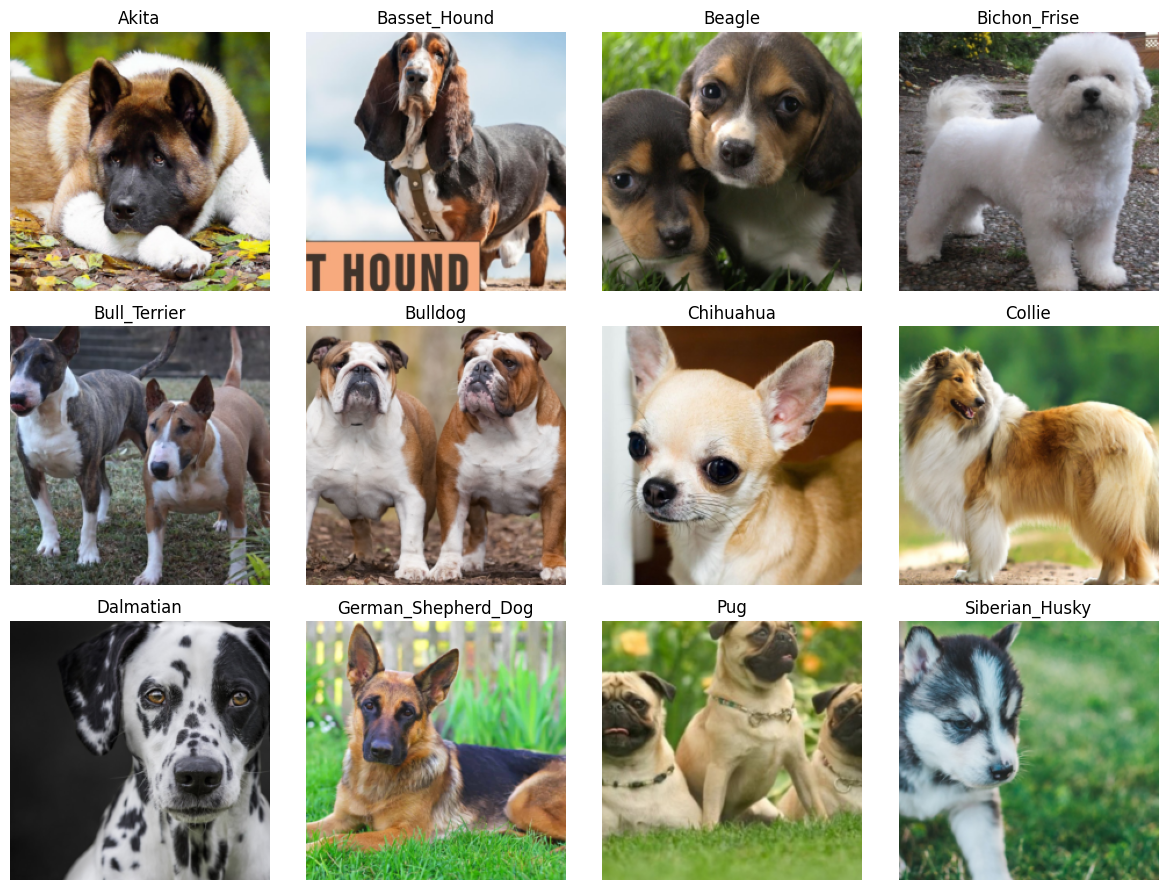

In [12]:
# Try to load the dataset and visualize it
train_loader, val_loader, class_names = load_data(data_dir=DATA_DIR, batch_size=BATCH_SIZE, input_size=INPUT_SIZE, mean=MEAN, std=STD)

# Visualize the data, each class one image
visualize_data(train_loader, class_names)

### Model

In [ ]:
import torch.nn as nn
from torchvision.models import (
    googlenet, GoogLeNet_Weights,
    resnet18, ResNet18_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    swin_t, Swin_T_Weights,
)

def get_model(name: str, num_classes: int, device: torch.device):
    """Return a pretrained model with dropout and a custom classification head."""
    name = name.lower()
    
    if name == "inception":
        weights = GoogLeNet_Weights.DEFAULT
        model = googlenet(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Sequential( nn.Dropout(p=0.4), nn.Linear(in_features, num_classes))
        model.aux_logits = False
        model.aux1 = None
        model.aux2 = None

    elif name == "resnet":
        weights = ResNet18_Weights.DEFAULT
        model = resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(nn.Dropout(p=0.4), nn.Linear(in_features, num_classes))

    elif name == "efficientnet":
        weights = EfficientNet_B0_Weights.DEFAULT
        model = efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(p=0.4), nn.Linear(in_features, num_classes))

    elif name == "swin":
        weights = Swin_T_Weights.DEFAULT
        model = swin_t(weights=weights)
        in_features = model.head.in_features
        model.head = nn.Sequential(nn.Dropout(p=0.4), nn.Linear(in_features, num_classes))

    else:
        raise ValueError(f"Unknown model '{name}'. Choose from: inception, resnet, efficientnet, swin.")
    return model.to(device)


In [14]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [15]:
from collections import OrderedDict

def summarize_all_models(num_classes: int, device: torch.device) -> OrderedDict:
    """
    Instantiate each supported model at its smallest variant,
    count trainable parameters, and return an ordered summary.
    """
    model_names = ["efficientnet", "inception", "resnet", "swin"]
    summary = OrderedDict()
    
    for name in model_names:
        model = get_model(name, num_classes, device)
        summary[name] = count_parameters(model)
    
    return summary

In [16]:
# Usage
from pprint import pprint

param_summary = summarize_all_models(NUM_CLASSES, DEVICE)
pprint({k: f"{v:,}" for k, v in param_summary.items()})

{'efficientnet': '4,022,920',
 'inception': '5,612,204',
 'resnet': '11,182,668',
 'swin': '27,528,582'}


## Trainer Class

In [17]:
# Visualize some predictions from the model
def show_predictions(model, dataloader, title, class_names):
    """Visualize some predictions from the model."""
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(dim=1)

    fig, axs = plt.subplots(2, 4, figsize=(12, 6))
    axs = axs.flatten()
    for i in range(8):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = (img * 0.5) + 0.5  # unnormalize
        axs[i].imshow(img)
        axs[i].axis("off")
        axs[i].set_title(f"GT: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
    plt.suptitle(title)
    plt.tight_layout()
    # plt.savefig(f"{title.replace(' ', '_')}.png")
    # print(f"Saved image predictions to: {title.replace(' ', '_')}.png")

In [18]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.optim.lr_scheduler import StepLR

class Trainer:
    def __init__(
        self,
        data_dir: str,
        batch_size: int,
        device: torch.device,
        epochs: int = 5,
        lr: float = 1e-4,
        weight_decay: float = 0.0,
        run_dir: str = "runs",
        ckpt_dir: str = "checkpoints",
        input_size: int = 224,
        mean: tuple = (0.5, 0.5, 0.5),
        std: tuple = (0.5, 0.5, 0.5),
    ):
        self.device      = device
        self.epochs      = epochs
        self.lr          = lr
        self.weight_decay= weight_decay

        # Load data once
        self.train_loader, self.val_loader, self.class_names = load_data(
            data_dir=data_dir,
            batch_size=batch_size,
            input_size=input_size,
            mean=mean,
            std=std
        )

        # Prepare directories
        self.run_dir  = run_dir;  os.makedirs(run_dir,  exist_ok=True)
        self.ckpt_dir = ckpt_dir; os.makedirs(ckpt_dir, exist_ok=True)

    @staticmethod
    def _plot_confusion_matrix(
        y_true,
        y_pred,
        class_names,
        title,
        figsize=(6, 5),
        font_size=8
    ):
        cm = confusion_matrix(y_true, y_pred)
        labels = [lab.replace("_", " ") for lab in class_names]

        fig, ax = plt.subplots(figsize=figsize, dpi=100)
        disp = ConfusionMatrixDisplay(cm, display_labels=labels)
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")

        # Resize tick labels
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=font_size)
        ax.set_yticklabels(labels, rotation=0, fontsize=font_size)

        ax.set_xlabel("Predicted", fontsize=font_size)
        ax.set_ylabel("Actual", fontsize=font_size)
        ax.set_title(title, fontsize=font_size + 2)

        plt.tight_layout()
        plt.show()
        
    def _iterate(self, model, loader, train: bool):
        """
        Single epoch over train or val loader.
        Returns (loss_sum, correct, total, all_preds, all_labels)
        """
        mode = model.train if train else model.eval
        mode()

        criterion = nn.CrossEntropyLoss()
        all_preds, all_labels = [], []
        loss_sum, correct, total = 0.0, 0, 0

        with torch.set_grad_enabled(train):
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)
                outputs = model(X)
                loss = criterion(outputs, y)
                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()

                preds = outputs.argmax(dim=1)
                loss_sum += loss.item()
                correct  += (preds == y).sum().item()
                total    += y.size(0)

                all_preds.extend(preds.cpu().tolist())
                all_labels.extend(y.cpu().tolist())

        return loss_sum, correct, total, all_preds, all_labels

    def fit(self, model: nn.Module, model_name: str):
        """
        Train model and checkpoint best weights.
        """
        model = model.to(self.device)
        self.optimizer = optim.Adam(model.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        self.scheduler = StepLR(self.optimizer, step_size=3, gamma=0.5)
        writer = SummaryWriter(log_dir=os.path.join(self.run_dir, model_name))
        ckpt_path = os.path.join(self.ckpt_dir, f"{model_name}_model.pt")

        best_val_acc = 0.0
        for epoch in range(1, self.epochs + 1):
            # train
            tr_loss, tr_corr, tr_total, _, _ = self._iterate(model, self.train_loader, train=True)
            train_acc = tr_corr / tr_total

            # validate
            val_loss, val_corr, val_total, all_preds, all_labels = self._iterate(model, self.val_loader, train=False)
            val_acc = val_corr / val_total

            # log & schedule
            writer.add_scalar("Loss/train", tr_loss, epoch)
            writer.add_scalar("Loss/val",   val_loss, epoch)
            writer.add_scalar("Acc/train",  train_acc, epoch)
            writer.add_scalar("Acc/val",    val_acc,   epoch)
            self.scheduler.step()

            print(f"[{epoch}/{self.epochs}] {model_name} — train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")

            # checkpoint
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), ckpt_path)

        writer.close()
        print(f"{model_name} training complete. Best val_acc: {best_val_acc:.4f}")
        print(f"Total params: {count_parameters(model):,}")
        print(f"Checkpoint saved at: {ckpt_path}")

        # return final preds for convenience
        return all_labels, all_preds

    def evaluate(self, model: nn.Module, model_name: str, load_checkpoint: bool = True, show_samples: bool = False):
        """
        Load checkpoint, run inference, and show conf matrix + sample preds.
        """
        model = model.to(self.device)
        ckpt_path = os.path.join(self.ckpt_dir, f"{model_name}_model.pt")
        if load_checkpoint:
            model.load_state_dict(torch.load(ckpt_path, map_location=self.device))

        _, _, _, all_preds, all_labels = self._iterate(model, self.val_loader, train=False)

        self._plot_confusion_matrix(
            all_labels, all_preds, self.class_names, title=f"{model_name} Confusion Matrix"
        )

        if show_samples:
            show_predictions(model, self.val_loader, title=f"{model_name} Sample Predictions", class_names=self.class_names)


In [19]:
# All the model names we support
model_names = ["efficientnet", "inception", "resnet", "swin"]

In [20]:
# Create a Trainer instance
trainer = Trainer(DATA_DIR, BATCH_SIZE, DEVICE, epochs=EPOCHS, lr=1e-4, weight_decay=1e-4)

Training samples: 1139, Validation samples: 285


In [21]:
# Train All Models
# Loop through each architecture, instantiate, and train.
for name in model_names:
    # Instantiate the model
    model = get_model(name, num_classes=NUM_CLASSES, device=DEVICE)
    print(f"\n=== Training {name} ===")
    # Train (logs to runs/{name}, saves best checkpoint to checkpoints/{name}_model.pt)
    trainer.fit(model, name)


=== Training efficientnet ===
[1/5] efficientnet — train_acc: 0.4012, val_acc: 0.8281
[2/5] efficientnet — train_acc: 0.8859, val_acc: 0.9053
[3/5] efficientnet — train_acc: 0.9421, val_acc: 0.9298
[4/5] efficientnet — train_acc: 0.9728, val_acc: 0.9614
[5/5] efficientnet — train_acc: 0.9781, val_acc: 0.9614
efficientnet training complete. Best val_acc: 0.9614
Total params: 4,022,920
Checkpoint saved at: checkpoints/efficientnet_model.pt

=== Training inception ===
[1/5] inception — train_acc: 0.5171, val_acc: 0.9053
[2/5] inception — train_acc: 0.9315, val_acc: 0.9368
[3/5] inception — train_acc: 0.9728, val_acc: 0.9544
[4/5] inception — train_acc: 0.9939, val_acc: 0.9579
[5/5] inception — train_acc: 0.9982, val_acc: 0.9579
inception training complete. Best val_acc: 0.9579
Total params: 5,612,204
Checkpoint saved at: checkpoints/inception_model.pt

=== Training resnet ===
[1/5] resnet — train_acc: 0.6760, val_acc: 0.9368
[2/5] resnet — train_acc: 0.9798, val_acc: 0.9579
[3/5] resnet 


=== Evaluating efficientnet ===


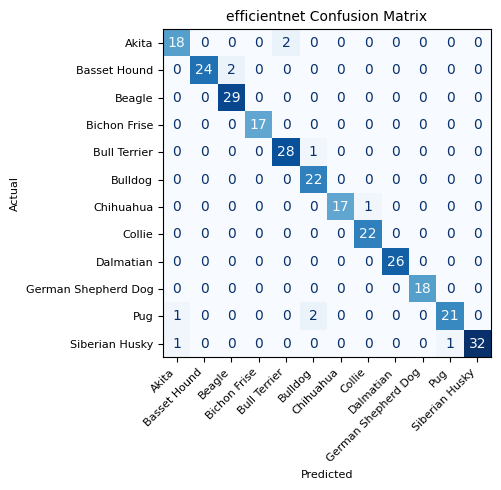


=== Evaluating inception ===


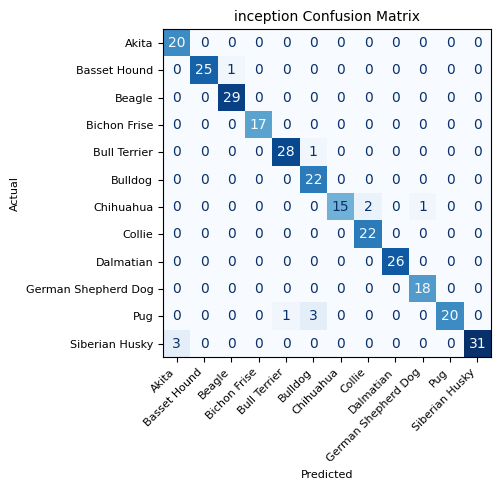


=== Evaluating resnet ===


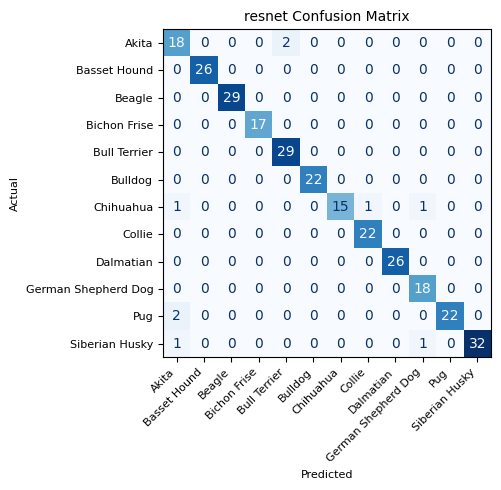


=== Evaluating swin ===


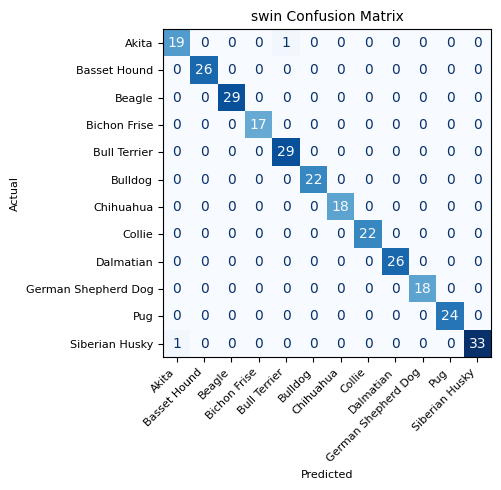

In [22]:
# Evaluate All Models
for name in model_names:
    # Instantiate the model architecture
    model = get_model(name, num_classes=NUM_CLASSES, device=DEVICE)
    print(f"\n=== Evaluating {name} ===")
    # Evaluate (plots confusion matrix and sample predictions)
    trainer.evaluate(model, name)

## TensorBoard

In [23]:
import subprocess
import time
import webbrowser

In [24]:
def start_tensorboard(logdir="runs", port=6006):
    """
    Starts TensorBoard as a background process and opens it in your default browser.
    Returns the process handle so you can terminate it later.
    """
    tb_cmd = [
        "tensorboard",
        f"--logdir={logdir}",
        f"--port={port}",
        "--host=localhost"
    ]
    
    # Start the process
    print(f"Starting TensorBoard on port {port}...")
    process = subprocess.Popen(tb_cmd)
    
    # Give it a second to get going
    time.sleep(2)
    
    # Open in browser automatically
    url = f"http://localhost:{port}"
    print(f"Opening {url} in your default browser...")
    webbrowser.open(url)
    
    return process


def stop_tensorboard(process):
    """
    Stops the TensorBoard process started by `start_tensorboard()`.
    """
    print("Stopping TensorBoard...")
    process.terminate()  # or process.kill()


In [25]:
process = start_tensorboard(logdir="runs", port=6008)

Starting TensorBoard on port 6008...


TensorFlow installation not found - running with reduced feature set.

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

E0424 17:34:20.181897 136153409464128 program.py:300] TensorBoard could not bind to port 6008, it was already in use
ERROR: TensorBoard could not bind to port 6008, it was already in use


Opening http://localhost:6008 in your default browser...


In [26]:
# stop_tensorboard(process)